# 02 Bias and Fairness Analysis

This notebook documents the bias and fairness assessment of the cleaned credit
applications dataset. We systematically evaluate potential disparities in loan
approval outcomes across protected and related attributes, focusing on
**gender bias**, **age-based discrimination**, and **proxy discrimination**.

The analysis includes the computation of **fairness metrics** (such as the
Disparate Impact Ratio), **statistical significance testing**, and exploratory
analysis of **interaction effects** between demographic attributes.
The goal is to identify whether the credit approval process exhibits patterns
that may indicate unfair or discriminatory outcomes.

| Section | Description |
|--------|-------------|
| Gender Analysis | Evaluation of model outcomes across gender groups to identify potential disparities or bias. |
| Age Analysis | Assessment of how predictions differ across age groups and whether age influences model decisions unfairly. |
| Age and Gender Interaction | Analysis of combined effects of age and gender to detect intersectional bias. |
| ZIP Proxy Analysis | Investigation of ZIP code as a proxy variable for sensitive attributes such as socioeconomic status or ethnicity. |

# Imports

In [1]:

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate

# Data loading

In [2]:
# Load cleaned dataset (output from data quality pipeline)
df_original = pd.read_csv("../data/cleaned_credit_applications.csv")  # adjust path if needed

# Create working copy for analysis
df = df_original.copy()

print("Dataset loaded successfully from cleaned CSV")
print(f"Shape: {df.shape[0]} records, {df.shape[1]} columns")
df.head()

Dataset loaded successfully from cleaned CSV
Shape: 500 records, 21 columns


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_164,"[{'category': 'Utilities', 'amount': 218}, {'c...",2024-01-15T00:00:00Z,Brian Brown,brian.brown61@yahoo.com,586-29-4288,192.168.240.12,Male,1978-10-04,10004.0,...,117,0.14,34221,True,NaN,NaN,4.1,62000.0,NaN,NaN
1,app_179,"[{'category': 'Utilities', 'amount': 842}, {'c...",2026-03-15T00:00:00Z,Paul Roberts,paul.roberts46@yahoo.com,880-83-3129,172.21.233.185,Male,12/07/1993,10092.0,...,30,0.24,31966,True,NaN,NaN,3.4,42000.0,NaN,NaN
2,app_226,"[{'category': 'Travel', 'amount': 726}]",NaN,Susan Flores,susan.flores95@mail.com,817-96-6416,192.168.196.9,Female,1982/04/18,90231.0,...,61,0.17,66276,True,NaN,vacation,6.1,46000.0,NaN,NaN
3,app_183,"[{'category': 'Healthcare', 'amount': 838}]",2024-01-15T00:00:00Z,Patrick Lewis,patrick.lewis88@outlook.com,956-25-2870,192.168.39.77,Male,09/20/1998,10003.0,...,12,0.17,1661,True,NaN,NaN,4.9,16000.0,NaN,NaN
4,app_168,"[{'category': 'Groceries', 'amount': 687}, {'c...",2024-01-15T00:00:00Z,Larry Thompson,larry.thompson20@yahoo.com,674-78-4391,192.168.148.88,M,1997-03-31,10092.0,...,29,0.28,22361,True,NaN,NaN,6.1,65000.0,NaN,NaN


# Gender analysis

### Interpretation (Gender)

We will compare loan approval outcomes between **male** and **female** applicants using the cleaned dataset.

- **Approval rates:** Female applicants have an approval rate of **52.3%** (101/193) vs **67.5%** for male applicants (131/194).
- **Disparate Impact (DI):** The DI ratio (Female/Male) is **0.775**, which is **below the 0.80 four-fifths threshold**, indicating potential adverse impact against female applicants.
- **Statistical test:** A chi-square test shows a **statistically significant association** between gender and approval (p = **0.0032**). The effect size is **small-to-moderate** (Phi/Cramér’s V = **0.150**), meaning the difference is real but not the only driver of approval decisions.

Overall, the gender approval gap appears meaningful and warrants deeper investigation (e.g., proxies such as geography and confounders such as income/DTI) before drawing causal conclusions.

In [3]:
gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

In [4]:
#filtering to male/female only
df_g = df[df[gender_col].isin(["Male", "Female"]) & df[decision_col].notna()].copy()

In [5]:
gender_summary = (
    df_g.groupby(gender_col)[decision_col]
        .agg(n_total="size", n_approved="sum", approval_rate="mean")
)

display(gender_summary)

,n_total,n_approved,approval_rate
applicant_info.gender,,,
Female,193,101,0.523316
Male,194,131,0.675258


In [6]:
# Disparate Impact (DI): Female/Male 
rate_male = gender_summary.loc["Male", "approval_rate"]
rate_female = gender_summary.loc["Female", "approval_rate"]

di = rate_female / rate_male

print(f"Approval rate (Male):   {rate_male:.3f}")
print(f"Approval rate (Female): {rate_female:.3f}")
print(f"Disparate Impact (Female/Male): {di:.3f}")

# Four-fifths rule classification
if di < 0.80:
    print("Four-Fifths Rule: FAIL (DI < 0.80) → potential adverse impact")
else:
    print("Four-Fifths Rule: PASS (DI ≥ 0.80)")


Approval rate (Male):   0.675
Approval rate (Female): 0.523
Disparate Impact (Female/Male): 0.775
Four-Fifths Rule: FAIL (DI < 0.80) → potential adverse impact


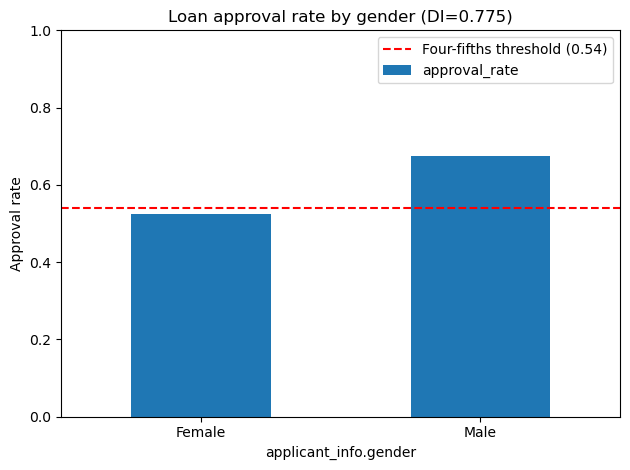

In [7]:
threshold = 0.8 * rate_male

fig, ax = plt.subplots()
gender_summary["approval_rate"].plot(kind="bar", ax=ax, rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Approval rate")
ax.set_title(f"Loan approval rate by gender (DI={di:.3f})")
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
           label=f"Four-fifths threshold ({threshold:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

The chart shows the loan approval rates by gender along with the four-fifths fairness threshold. Male applicants have an approval rate of 67.5%, while female applicants have an approval rate of 52.3%. The dashed red line represents the 80% threshold relative to the male approval rate (0.54). Since the female approval rate falls below this threshold, the results indicate a potential adverse impact against female applicants according to the four-fifths rule.

### Significance test: Chi-square (Gender × Approval) + Cramér’s V

The Chi-square test checks whether that difference is statistically significant or could just be random noise, and Cramér’s V measures effect size (strength of association).

In [8]:
# 2×2 crosstab: gender × approval (using the same filtered df_g)
ct_gender = pd.crosstab(df_g[gender_col], df_g[decision_col])
display(ct_gender)

chi2, p, dof, expected = chi2_contingency(ct_gender)

# Cramér's V (for 2×2, equals Phi)
n = ct_gender.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_gender.shape) - 1)))

print(f"Chi-square: chi2={chi2:.4f}, p={p:.6f}, dof={dof}")
print(f"Cramér’s V (effect size): {cramers_v:.3f}")
print("Conclusion:", "Significant association" if p < 0.05 else "No significant association")

decision.loan_approved,False,True
applicant_info.gender,,
Female,92,101
Male,63,131


Chi-square: chi2=8.6805, p=0.003216, dof=1
Cramér’s V (effect size): 0.150
Conclusion: Significant association


**Interpretation:**  
The chi-square test evaluates whether approval decisions are independent of gender. A statistically significant result (p < 0.05) suggests approval rates differ by gender beyond what we would expect from random variation. Cramér’s V quantifies the **strength** of the association (values closer to 0 are weaker; closer to 1 are stronger).

### Outcomes among approved applicants (interest rate and approved amount)

In [9]:
interest_col = "decision.interest_rate"
amount_col = "decision.approved_amount"

needed = [interest_col, amount_col]
missing = [c for c in needed if c not in df.columns]

if missing:
    print(f"Skipping outcomes-by-gender (missing columns): {missing}")
else:
    df_approved = df_g[df_g[decision_col] == True].copy()

    outcomes_by_gender = (
        df_approved.groupby(gender_col)[[interest_col, amount_col]]
        .mean()
        .rename(columns={
            interest_col: "avg_interest_rate",
            amount_col: "avg_approved_amount"
        })
    )

    display(outcomes_by_gender)

,avg_interest_rate,avg_approved_amount
applicant_info.gender,,
Female,4.477228,45881.188119
Male,4.612214,49778.625954


**Interpretation:**  
Among approved applicants, we compare whether *downstream outcomes* (pricing and approved amount) differ by gender. This helps distinguish “approval bias” from “allocation/terms bias” (e.g., similar approval chances but systematically smaller amounts or different interest rates).

### Confounder-controlled check (Logistic Regression)

In [10]:
gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

feature_cols = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
]

# Keep valid rows
df_lr = df[df[gender_col].isin(["Male", "Female"]) & df[decision_col].notna()].copy()
df_lr = df_lr.dropna(subset=feature_cols)

# Encode Female=1, Male=0
df_lr["is_female"] = (df_lr[gender_col] == "Female").astype(int)

X_base = df_lr[feature_cols]
X_full = df_lr[feature_cols + ["is_female"]]
y = df_lr[decision_col].astype(int)

# Standardise features
scaler = StandardScaler()
Xb = scaler.fit_transform(X_base)
Xf = scaler.fit_transform(X_full)

# Fit models
model_base = LogisticRegression(max_iter=2000).fit(Xb, y)
model_full = LogisticRegression(max_iter=2000).fit(Xf, y)

# Gender effect (last coefficient = is_female)
gender_coef = model_full.coef_[0][-1]
odds_ratio = float(np.exp(gender_coef))

print(f"Gender coefficient (Female=1): {gender_coef:.3f}")
print(f"Odds ratio (Female vs Male): {odds_ratio:.3f}")
print("Interpretation: OR < 1 means lower odds of approval for females after controlling for the financial variables.")


Gender coefficient (Female=1): -0.337
Odds ratio (Female vs Male): 0.714
Interpretation: OR < 1 means lower odds of approval for females after controlling for the financial variables.


**Confounder-controlled check (Logistic Regression):**  
To test whether the gender gap could be explained by differences in financial profiles, we fitted a logistic regression using key financial covariates (income, credit history, debt-to-income, savings) and then added a gender indicator.
 A negative coefficient means that being female is associated with a lower predicted probability of approval, after controlling for the included financial variables. So even after taking into account income, savings, debt-to-income, and credit history, the model still finds a disadvantage associated with female applicants.
The odds ratio means that holding the included financial variables constant, female applicants have about 0.714 times the odds of approval compared with male applicants (women have about 28.6% lower odds of approval than otherwise similar men in this model). 


### Conclusion on gender analysis:

 Overall, the gender analysis shows a clear and consistent disparity in loan approval outcomes. Female applicants have a lower approval rate than male applicants, and the Disparate Impact ratio of 0.775 falls below the 0.80 four-fifths threshold, indicating potential adverse impact. This difference is also statistically significant, as the Chi-square test shows that approval outcomes are not independent of gender. Although the association is modest in size, it is still meaningful from a fairness perspective. Among approved applicants, women receive slightly lower average interest rates, but they are approved less often overall. Most importantly, the logistic regression indicates that female applicants still have lower odds of approval even after controlling for key financial characteristics such as income, credit history, debt-to-income ratio, and savings. Taken together, these findings suggest that the observed gender gap is persistent and cannot be fully explained by the financial variables included in the analysis, pointing to potential gender-related bias in the approval process.


# Age Analysis

In [11]:
dob_col = "applicant_info.date_of_birth"
decision_col = "decision.loan_approved"

# Parse DOB and define reference date
df["dob"] = pd.to_datetime(df[dob_col], errors="coerce")
ref_date = pd.Timestamp("2024-12-31")  # fixed reference for reproducibility

# Compute age in years
df["age"] = (ref_date - df["dob"]).dt.days / 365.25

# Clean unrealistic ages
df.loc[(df["age"] < 18) | (df["age"] > 100), "age"] = np.nan

# Age buckets
age_bins = [0, 30, 50, 120]
age_labels = ["<30", "30–50", "50+"]

df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

print("Age group counts (including NaN):")
display(df["age_group"].value_counts(dropna=False))
print(f"Missing age proportion: {df['age'].isna().mean():.3f}")

Age group counts (including NaN):


age_group
30–50    204
NaN      161
<30       68
50+       67
Name: count, dtype: int64

Missing age proportion: 0.322


In [12]:
df['age'].isna().mean()

0.322

In [13]:
mask_age = df["age_group"].notna() & df[decision_col].notna()

approval_by_age = (
    df.loc[mask_age, ["age_group", decision_col]]
      .groupby("age_group", observed=False)
      .agg(
          n_total=(decision_col, "size"),
          n_approved=(decision_col, "sum"),
          approval_rate=(decision_col, "mean"),
      )
)

approval_by_age

,n_total,n_approved,approval_rate
age_group,,,
<30,68,27,0.397059
30–50,204,127,0.622549
50+,67,40,0.597015


In [14]:
rate_ref = approval_by_age.loc["30–50", "approval_rate"]

di_vs_ref = (approval_by_age["approval_rate"] / rate_ref).rename("DI_vs_30–50")
age_di_table = approval_by_age.join(di_vs_ref)

age_di_table

,n_total,n_approved,approval_rate,DI_vs_30–50
age_group,,,,
<30,68,27,0.397059,0.637795
30–50,204,127,0.622549,1.000000
50+,67,40,0.597015,0.958985


In [15]:
di_under30 = age_di_table.loc["<30", "DI_vs_30–50"]
di_50plus  = age_di_table.loc["50+", "DI_vs_30–50"]

print(f"DI <30 vs 30–50: {di_under30:.3f} {'(FLAG <0.8)' if di_under30 < 0.8 else ''}")
print(f"DI 50+ vs 30–50: {di_50plus:.3f} {'(FLAG <0.8)' if di_50plus < 0.8 else ''}")

DI <30 vs 30–50: 0.638 (FLAG <0.8)
DI 50+ vs 30–50: 0.959 


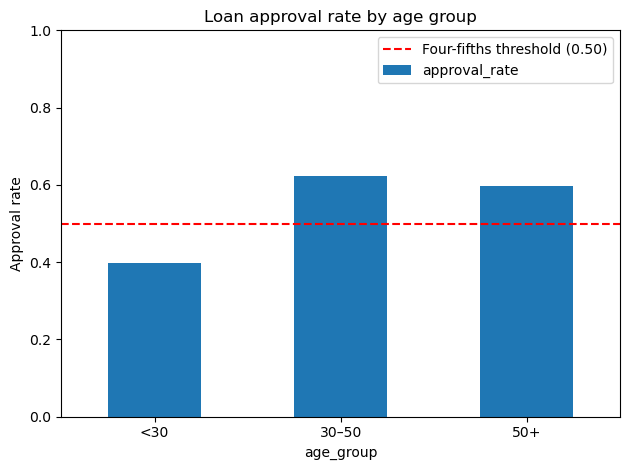

In [16]:
threshold = 0.8 * rate_ref

fig, ax = plt.subplots()
approval_by_age["approval_rate"].plot(kind="bar", ax=ax, rot=0)

ax.set_ylabel("Approval rate")
ax.set_title("Loan approval rate by age group")
ax.set_ylim(0, 1)

ax.axhline(
    y=threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Four-fifths threshold ({threshold:.2f})"
)

ax.legend()
plt.tight_layout()
plt.show()

In [17]:
cont_age = pd.crosstab(df.loc[mask_age, "age_group"], df.loc[mask_age, decision_col])
display(cont_age)

chi2, p, dof, expected = chi2_contingency(cont_age)

# Cramér's V
n = cont_age.to_numpy().sum()
k = min(cont_age.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Chi-square test: Age Group vs Loan Approval")
print(f"Chi2 = {chi2:.4f}, p-value = {p:.6f}, dof = {dof}")
print(f"Cramer's V = {cramers_v:.3f}")
print("Result: Statistically significant association." if p < 0.05
      else "Result: No statistically significant association detected.")

decision.loan_approved,False,True
age_group,,
<30,41,27
30–50,77,127
50+,27,40


Chi-square test: Age Group vs Loan Approval
Chi2 = 10.8027, p-value = 0.004510, dof = 2
Cramer's V = 0.179
Result: Statistically significant association.


,avg_interest_rate,avg_approved_amount,n_approved
age_group,,,
<30,4.603704,44925.925926,27
30–50,4.560630,49086.614173,127
50+,4.432500,50250.000000,40


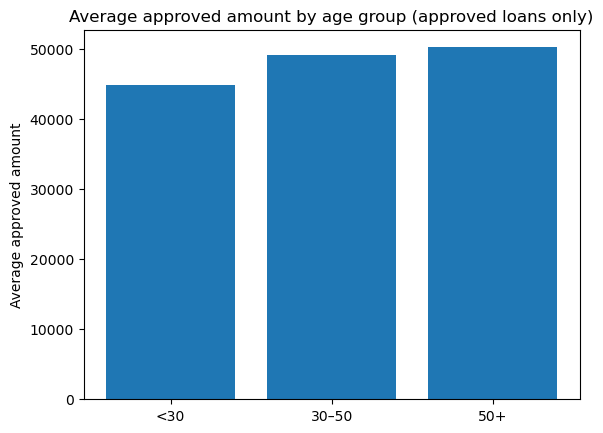

In [18]:
interest_col = "decision.interest_rate"
amount_col = "decision.approved_amount"

approved_mask = df["age_group"].notna() & (df[decision_col] == True)

missing = [c for c in [interest_col, amount_col] if c not in df.columns]
if missing:
    print(f"Skipping outcomes_by_age (missing columns): {missing}")
else:
    outcomes_by_age = (
        df.loc[approved_mask, ["age_group", interest_col, amount_col]]
          .groupby("age_group", observed=False)
          .agg(
              avg_interest_rate=(interest_col, "mean"),
              avg_approved_amount=(amount_col, "mean"),
              n_approved=(amount_col, "size"),
          )
    )
    display(outcomes_by_age)

    plt.figure()
    plt.bar(outcomes_by_age.index.astype(str), outcomes_by_age["avg_approved_amount"])
    plt.ylabel("Average approved amount")
    plt.title("Average approved amount by age group (approved loans only)")
    plt.show()

### Age-based Approval patterns

**Age Data Preparation**:

To assess potential age-related disparity in lending decisions, we derived an age variable from applicant_info.date_of_birth. Dates of birth were parsed to datetime (invalid or missing values become NaT), and age was computed using a fixed reference date for reproducibility. Applicants with missing DOB (and therefore missing age group) were excluded from age-based fairness metrics to avoid distorting group comparisons.


**Age Group Distribution**

We bucketed applicants into three age groups to enable stable comparisons:

• <30: 68 applicants

• 30–50: 204 applicants

• 50+: 67 applicants


**Aproval Rate Disparity**

Approval rates differ substantially across age groups:

• <30: 39.7%

• 30–50: 62.3%

• 50+: 59.7%

Treating 30-50 as the reference group, the Disparate Impact (DI) ratios are:

| Comparison   | DI Ratio | Below 0.80 threshold? |
| ------------ | -------: | :-------------------: |
| <30 vs 30–50 |    0.638 |          Yes          |
| 50+ vs 30–50 |    0.959 |           No          |

The primary disparity is between younger applicants (<30) and the other age groups. The under-30 group’s approval rate is only about 64% of the 30–50 group’s approval rate, which falls below the four-fifths (0.80) guideline and flags potential adverse impact for younger applicants.

**Statisticsl Test (Age Group vs Approval)**

To confirm the pattern is unlikely to be due to random variation, we ran a chi-square test of independence between age group and loan approval outcome. The test indicates a statistically significant association:

• χ² = 10.80, p = 0.00451, dof = 2

• Cramér’s V = 0.179 (small-to-moderate association)

This supports that approval outcomes vary by age group in this dataset (association evidence, not causal proof).


**Outcome Metrics Among Approved Applicants**

We also examined whether disparities extend beyond approval decisions to loan terms among approved applicants:

• Average interest rates are broadly similar across age groups (differences are small).

• Average approved amounts increase with age, with <30 receiving the lowest average approved amount and 50+ the highest.

This suggests the disparity is not only about who gets approved, but may also affect the scale of credit granted once approved.


**Possible Confounders**

Some of the observed differences may reflect age-correlated financial factors (e.g., shorter credit history for younger applicants, different income distributions, or higher debt-to-income ratios). These factors may contribute to approval differences even without direct age-based decision rules. However, if age-correlated variables act as proxies for age, they can still produce indirect age discrimination, which is why monitoring and governance controls are necessary.

**Sugested Mitigations**:

• Feature review: Evaluate age-correlated features (e.g., credit history months) and assess whether they create disproportionate impact on younger applicants.

• Regular monitoring: Track approval rates and DI ratios by age group over time, and trigger review if DI (<30 vs 30–50) remains below 0.80.

• Threshold review: If business rules or model thresholds create large age-group gaps, review whether adjustments are justified by risk evidence.

• Outcome monitoring: Monitor not only approval rates but also approved amounts by subgroup to detect “downstream” disparities in credit allocation.

# Age and Gender Interaction

In [19]:
gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

# Keep only Male/Female, valid age group, and non-missing decisions
mask_ag = (
    df["age_group"].notna()
    & df[decision_col].notna()
    & df[gender_col].isin(["Male", "Female"])
)

# Approval rate by age group AND gender (table)
age_gender_approval = (
    df.loc[mask_ag, ["age_group", gender_col, decision_col]]
      .groupby(["age_group", gender_col], observed=False)
      .agg(approval_rate=(decision_col, "mean"), n_total=(decision_col, "size"))
      .reset_index()
)

# Pivot to wide format for plotting approval rates
pivot_rates = age_gender_approval.pivot(index="age_group", columns=gender_col, values="approval_rate")
display(pivot_rates)


applicant_info.gender,Female,Male
age_group,,
<30,0.357143,0.476190
30–50,0.575000,0.643678
50+,0.541667,0.760000


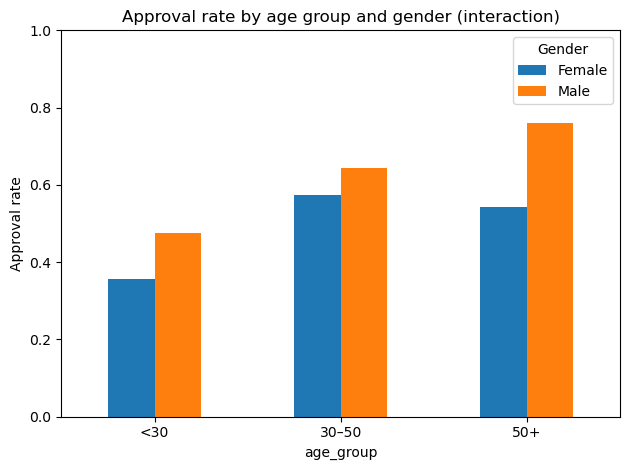

In [20]:
# Plot
pivot_rates.plot(kind="bar", rot=0)
plt.ylim(0, 1)
plt.ylabel("Approval rate")
plt.title("Approval rate by age group and gender (interaction)")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [21]:
pivot_counts = age_gender_approval.pivot(index="age_group", columns=gender_col, values="n_total")
display(pivot_counts)

applicant_info.gender,Female,Male
age_group,,
<30,28,21
30–50,80,87
50+,24,25


In [22]:
gap_table = pivot_rates.copy()
gap_table["gap_male_minus_female"] = gap_table["Male"] - gap_table["Female"]
gap_table

applicant_info.gender,Female,Male,gap_male_minus_female
age_group,,,
<30,0.357143,0.476190,0.119048
30–50,0.575000,0.643678,0.068678
50+,0.541667,0.760000,0.218333


### Age x Gender interpretation

To examine whether the gender approval gap is consistent across age groups, we computed approval rates for each age group × gender combination (intersectional analysis). This helps identify whether the overall gender disparity is driven by a specific age segment or persists across the population.

| Age Group | Female |  Male | Gap (M − F) |
| --------- | -----: | ----: | ----------: |
| <30       |  35.7% | 47.6% |     11.9 pp |
| 30–50     |  57.5% | 64.4% |      6.9 pp |
| 50+       |  54.2% | 76.0% |     21.8 pp |


Key patterns:

• The gender gap is present in all three age groups, indicating the overall female disadvantage is not explained by a single age segment.

• The gap is largest for the 50+ group (~21.8 percentage points), suggesting older female applicants may be the most affected subgroup.

• The smallest gap occurs in the 30–50 group (~6.9 percentage points), though males still have higher approval rates.

• The lowest approval rate overall is for women under 30 (~35.7%), combining both an age-related and gender-related disadvantage.

These interaction effects suggest that fairness interventions should not treat age and gender independently. If mitigation is applied, it may need to target the most impacted subgroup(s) (e.g., older women or younger women, depending on policy goals) rather than applying uniform corrections across the board.

# ZIP Proxy Analysis

Proxy discrimination happens when an apparently “neutral” feature (e.g., geography/ZIP code) is strongly related to a protected attribute (e.g., gender) and/or to the decision outcome (loan approval).

In this section we check three things:
1) **Stability**: keep only ZIPs with enough observations (to reduce noise).
2) **ZIP ↔ Approval**: whether approval rates vary strongly across ZIPs.
3) **ZIP ↔ Gender**: whether gender distribution differs across ZIPs (Cramér’s V), suggesting ZIP could act as a proxy for gender.

In [23]:
zip_col = "applicant_info.zip_code"
gender_col = "applicant_info.gender"
decision_col = "decision.loan_approved"

MIN_N = 5      # minimum applicants per ZIP to keep (stability)
TOP_N = 12     # number of ZIPs to display in plots

# Keep only rows with decision + zip available
df_zip = df.copy()
df_zip = df_zip[df_zip[decision_col].notna() & df_zip[zip_col].notna()].copy()

# Normalize ZIP as string (keep only digits; keep first 5 if longer; you can change to first 3 if you prefer)
df_zip["zip_clean"] = (
    df_zip[zip_col].astype(str)
      .str.extract(r"(\d+)", expand=False)
      .str.slice(0, 5)
)

df_zip = df_zip[df_zip["zip_clean"].notna()].copy()

# Stability filter
zip_counts = df_zip["zip_clean"].value_counts()
valid_zips = zip_counts[zip_counts >= MIN_N].index

df_zip = df_zip[df_zip["zip_clean"].isin(valid_zips)].copy()

print("Rows after ZIP filtering:", len(df_zip))
print("Unique ZIPs kept:", df_zip["zip_clean"].nunique())

Rows after ZIP filtering: 106
Unique ZIPs kept: 19


In [24]:
zip_stats = (
    df_zip.groupby("zip_clean", observed=False)[decision_col]
          .agg(n_applicants="size", approval_rate="mean")
          .sort_values("approval_rate", ascending=False)
)

display(zip_stats.head(10))
display(zip_stats.tail(10))

,n_applicants,approval_rate
zip_clean,,
10004,6,1.000000
10012,5,1.000000
10092,5,1.000000
10070,5,0.800000
90218,5,0.800000
90261,5,0.800000
90252,5,0.800000
10048,8,0.750000
10020,6,0.666667


,n_applicants,approval_rate
zip_clean,,
90273,5,0.600000
90237,5,0.600000
10002,5,0.600000
10041,5,0.600000
10057,6,0.500000
90284,7,0.428571
10003,5,0.400000
10019,6,0.333333
10096,7,0.285714


Visual approval rate by ZIP (TOP N)

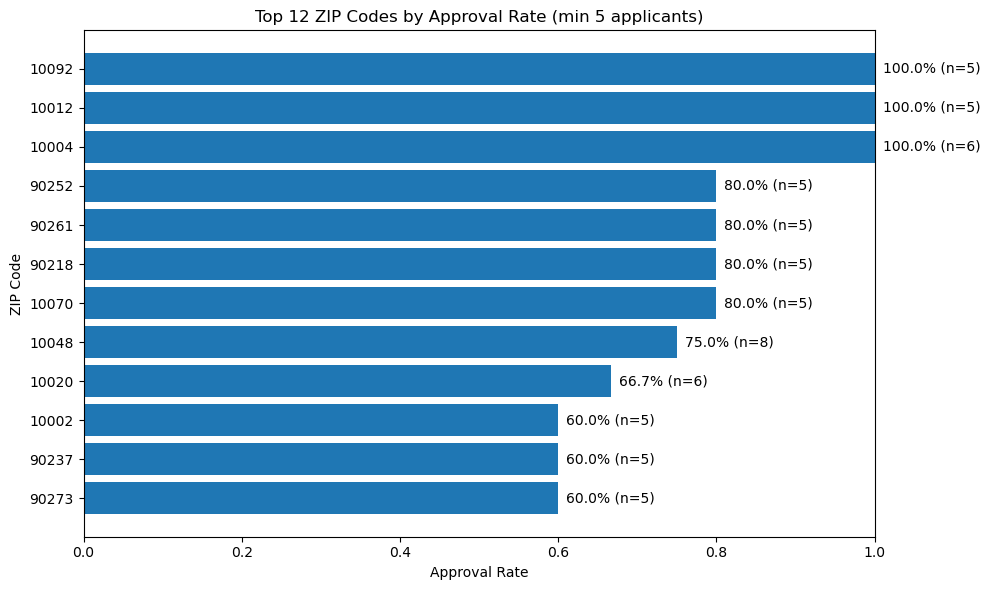

In [25]:
if zip_stats.empty:
    print("No ZIPs left after filtering. Try reducing MIN_N.")
else:
    top_zip = zip_stats.head(TOP_N).sort_values("approval_rate", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_zip.index.astype(str), top_zip["approval_rate"])
    ax.set_title(f"Top {TOP_N} ZIP Codes by Approval Rate (min {MIN_N} applicants)")
    ax.set_xlabel("Approval Rate")
    ax.set_ylabel("ZIP Code")
    ax.set_xlim(0, 1)

    # label bars with % and n
    for i, (rate, n) in enumerate(zip(top_zip["approval_rate"], top_zip["n_applicants"])):
        ax.text(rate + 0.01, i, f"{rate*100:.1f}% (n={n})", va="center")

    plt.tight_layout()
    plt.show()

Zip and gender association (Chi-square + Cramér’s V)

In [26]:
def cramers_v(contingency_table: pd.DataFrame) -> float:
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1))) if n > 0 else np.nan

# Keep only Male/Female for this proxy check
df_zip_g = df_zip[df_zip[gender_col].isin(["Male", "Female"])].copy()

ct_zip_gender = pd.crosstab(df_zip_g["zip_clean"], df_zip_g[gender_col])

if ct_zip_gender.shape[0] < 2 or ct_zip_gender.shape[1] < 2:
    print("Not enough variation to compute ZIP × Gender association after filtering.")
    display(ct_zip_gender)
else:
    chi2_zg, p_zg, dof_zg, _ = chi2_contingency(ct_zip_gender)
    v_zg = cramers_v(ct_zip_gender)

    print("Chi-square (ZIP × Gender):")
    print(f"  chi2 = {chi2_zg:.4f}, p = {p_zg:.6f}, dof = {dof_zg}")
    print(f"  Cramér's V = {v_zg:.3f}  (0=no association, 1=perfect association)")

Chi-square (ZIP × Gender):
  chi2 = 69.0936, p = 0.000000, dof = 18
  Cramér's V = 0.876  (0=no association, 1=perfect association)


ZIP and Approval association (Chi-square)

In [27]:
ct_zip_approval = pd.crosstab(df_zip["zip_clean"], df_zip[decision_col])

if ct_zip_approval.shape[0] < 2 or ct_zip_approval.shape[1] < 2:
    print("Not enough variation to compute ZIP × Approval association after filtering.")
    display(ct_zip_approval)
else:
    chi2_za, p_za, dof_za, _ = chi2_contingency(ct_zip_approval)
    print("Chi-square (ZIP × Approval):")
    print(f"  chi2 = {chi2_za:.4f}, p = {p_za:.6f}, dof = {dof_za}")

Chi-square (ZIP × Approval):
  chi2 = 25.1183, p = 0.121691, dof = 18


## Interpretation (ZIP proxy)

- **ZIP → Approval:** Approval rates vary across ZIP codes, which suggests location is associated with loan approval outcomes.  
- **Stability caution:** Many ZIP groups have small sample sizes (controlled by `MIN_N`), so extreme approval rates can be affected by sampling noise.  
- **ZIP ↔ Gender (proxy risk):** If Cramér’s V is meaningfully > 0 and statistically significant, it indicates gender distribution differs across ZIPs, so **ZIP code may partially act as a proxy for gender**.  

Overall, ZIP can be informative, but because it correlates with demographic structure, it should be treated carefully (monitoring, governance, and fairness checks are recommended).

# Conclusion

Overall, this bias and fairness audit suggests meaningful disparities in loan approval outcomes across protected characteristics. Female applicants show a lower approval rate than male applicants (with a Disparate Impact ratio below the 0.80 four-fifths threshold and a statistically significant chi-square result), and approval rates also vary notably by age group, with the youngest applicants facing the strongest adverse impact relative to the reference group. When age and gender are analysed together, the gender gap persists across all age bands and appears particularly pronounced among younger applicants, highlighting intersectional risk rather than a single isolated driver. Finally, ZIP code exhibits large variation in approval rates and a strong association with gender (high Cramér’s V), meaning geography can plausibly act as a proxy variable and reintroduce indirect discrimination even if gender is excluded from a model. These results are correlational (not causal) and subgroup sizes can be small, so conclusions should be treated as evidence for further investigation, governance, and mitigation—such as monitoring DI over time, reviewing/limiting proxy features like ZIP code, and considering fairness-aware interventions (e.g., reweighting or threshold review) alongside transparency around rejection reasons.
